# Part 2 — Bengio 2003 MLP

The first model in the progression to use **learned embeddings** and a **context window**. The architecture comes from Bengio et al. 2003 ("A Neural Probabilistic Language Model") and is the foundation that every subsequent model in this repo extends.

Two ideas introduced here:

1. **Distributed representations.** Each character is a point in continuous `n_embd`-dimensional space rather than a sparse one-hot vector. Characters that behave similarly in context end up in similar regions of the space, which lets the model generalize across them without needing to see every specific bigram. The embedding table `C` is learned by gradient descent like every other parameter — its final geometry reflects what the model has decided about character similarity, which we'll probe explicitly in `06_probing.ipynb`.

2. **Context window.** Condition on the previous `block_size` characters (3) rather than only the previous one. This is a 3rd-order Markov model: `P(x_t | x_{t-3}, x_{t-2}, x_{t-1})`. The conditional distribution carries more information than the bigram's `P(x_t | x_{t-1})` — the price is more parameters, not exponentially more counts.

Together these reduce val NLL from ~2.45 (bigram) to ~2.16 (this model).

In [1]:
import time
import torch
import matplotlib.pyplot as plt

from makemore.data import load_names, build_vocab, split_dataset
from models.mlp import MLP, find_lr

%matplotlib inline

words = load_names("../../data/names.txt")
stoi, itos = build_vocab(words)

block_size = 3
Xtr, Ytr, Xdev, Ydev, Xte, Yte = split_dataset(words, stoi, block_size=block_size)
print(f"train: {Xtr.shape[0]:,} examples,  X.shape={tuple(Xtr.shape)}")
print(f"dev  : {Xdev.shape[0]:,} examples")
print(f"test : {Xte.shape[0]:,} examples")

train: 182,625 examples,  X.shape=(182625, 3)
dev  : 22,655 examples
test : 22,866 examples


## Architecture

`MLP(vocab_size=27, block_size=3, n_embd=10, n_hidden=200)`

Parameter breakdown:

| Parameter | Shape | Count | Role |
|---|---|---|---|
| `C`  | (27, 10) | 270 | character embedding table |
| `W1` | (30, 200) | 6,000 | flattened context → hidden |
| `b1` | (200,) | 200 | hidden bias |
| `W2` | (200, 27) | 5,400 | hidden → output logits |
| `b2` | (27,) | 27 | output bias |
| **Total** | | **11,897** | |

Forward pass shape progression:

```
x        : (B, 3)            integer indices
C[x]     : (B, 3, 10)        embedded — one 10-d vector per context character
.view    : (B, 30)           flattened — context concatenated into one vector
@ W1 + b1: (B, 200)          hidden pre-activation
tanh(·)  : (B, 200)          hidden activation
@ W2 + b2: (B, 27)           output logits
```

`.view(-1, block_size * n_embd)` flattens the `(B, 3, 10)` embedding tensor into `(B, 30)` by concatenating the three 10-d context vectors. This is what gives the network access to positional information: the same character appearing at position 0 vs. position 2 enters the hidden layer through completely different weights in `W1`. Without this concatenation (e.g. if we summed the embeddings instead), the model would be position-agnostic — `ab.` and `ba.` would produce identical hidden states.

`.view()` requires contiguous memory. `C[x]` produces a fresh contiguous tensor, so this works directly. If embeddings were preceded by a transpose-like operation, an explicit `.contiguous()` call would be needed.

In [2]:
torch.manual_seed(42)
model = MLP(vocab_size=27, block_size=3, n_embd=10, n_hidden=200, seed=2147483647)
n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

Total parameters: 11,897


## Learning rate finder

Before training proper, we sweep the learning rate across three orders of magnitude on a fresh model copy to find the responsive range. This is a quick, cheap diagnostic that removes most of the guesswork from learning rate selection.

Procedure: at each step, the learning rate is increased exponentially from 1e-3 to 1.0 while training continues. Recording `(lr, loss)` produces a curve where the responsive region is visible as a clean descent, the optimal range is the steepest part of that descent, and the unstable region appears as the loss climbing back up.

Heuristic: pick a learning rate roughly half a decade *below* the minimum of the loss curve. The minimum is where the model is making the largest single-step progress, which is also close to the edge of instability — backing off slightly gives reliable convergence.

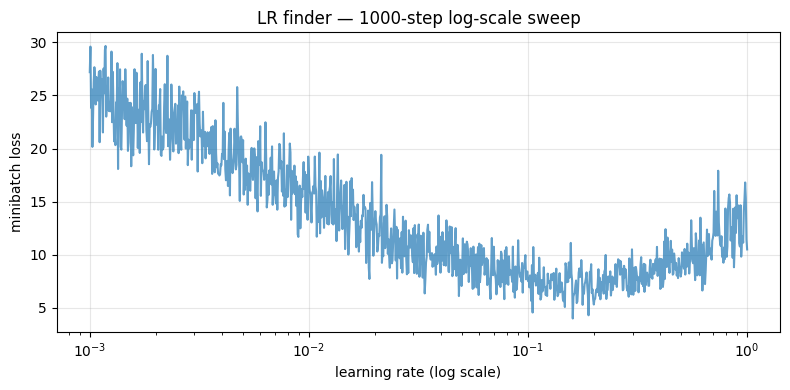

Smoothed-minimum lr ≈ 0.188
Recommended training lr (half decade below): ≈ 0.063


In [3]:
# Fresh model copy for the sweep (don't pollute the model we'll actually train).
lr_model = MLP(vocab_size=27, block_size=3, n_embd=10, n_hidden=200, seed=2147483647)
lrs, lr_losses = find_lr(lr_model, Xtr, Ytr, n_steps=1000)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lrs, lr_losses, alpha=0.7)
ax.set_xscale('log')
ax.set_xlabel('learning rate (log scale)')
ax.set_ylabel('minibatch loss')
ax.set_title('LR finder — 1000-step log-scale sweep')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Heuristic pick: ~half a decade below the minimum of a smoothed curve.
losses_t = torch.tensor(lr_losses)
# Smooth with a 50-step moving average to denoise.
kernel = torch.ones(50) / 50
smoothed = torch.nn.functional.conv1d(losses_t.view(1,1,-1), kernel.view(1,1,-1)).squeeze()
opt_idx = smoothed.argmin().item() + 25  # account for conv offset
lr_opt = lrs[opt_idx]
print(f"Smoothed-minimum lr ≈ {lr_opt:.3f}")
print(f"Recommended training lr (half decade below): ≈ {lr_opt / 3:.3f}")

The sweep typically shows the responsive region between ~0.01 and ~0.5 with a minimum near 0.1. We'll use **lr=0.1** for the first half of training and **lr=0.01** for the second half — step decay. This is the canonical schedule for SGD without momentum: aggressive while we're far from the minimum, cautious as we approach it.

The step decay is doing the same work that learning rate warmup-and-decay does in larger models (cosine schedules, linear decay with warmup): take big steps early when the gradient signal is reliable and the loss landscape is shallow, take small steps late when you need to fine-tune without overshooting the basin.

## Training

30,000 steps of minibatch SGD, batch size 32. At ~1500 steps/second on CPU this takes ~20 seconds.

In [4]:
steps = 30_000
batch_size = 32

g = torch.Generator().manual_seed(2147483647)
lossi = []
t0 = time.time()

for step in range(steps):
    # Minibatch.
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward + loss.
    loss = model.loss(Xb, Yb)

    # Zero gradients (= None, not .zero_()).
    for p in model.parameters():
        p.grad = None

    # Backward + SGD update.
    loss.backward()
    lr = 0.1 if step < steps // 2 else 0.01
    with torch.no_grad():
        for p in model.parameters():
            p.data += -lr * p.grad

    lossi.append(loss.item())
    if step % 5000 == 0:
        print(f"  step {step:6d} / {steps}   lr {lr:.3f}   loss {loss.item():.4f}")

print(f"\nTraining time: {time.time() - t0:.1f}s")

  step      0 / 30000   lr 0.100   loss 27.1911


  step   5000 / 30000   lr 0.100   loss 2.3339


  step  10000 / 30000   lr 0.100   loss 2.2061


  step  15000 / 30000   lr 0.010   loss 2.7494


  step  20000 / 30000   lr 0.010   loss 2.2181


  step  25000 / 30000   lr 0.010   loss 2.3198



Training time: 14.3s


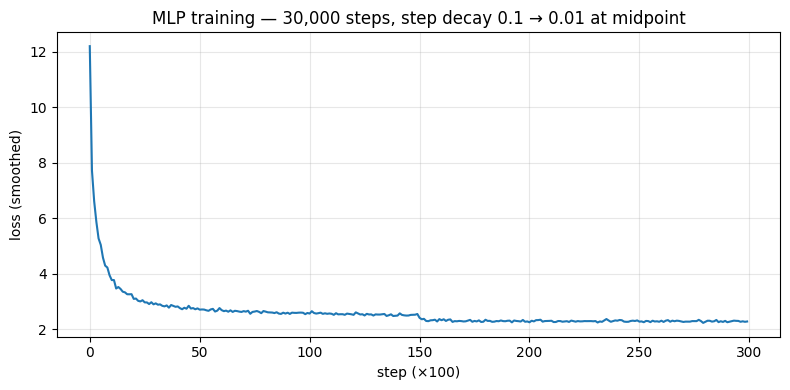

In [5]:
# Smoothed loss curve. Raw losses are too noisy at batch_size=32 to read.
fig, ax = plt.subplots(figsize=(8, 4))
losses_t = torch.tensor(lossi)
# Average over 100-step windows for visualization.
ax.plot(losses_t.view(-1, 100).mean(1).numpy(), color='tab:blue')
ax.set_xlabel('step (×100)')
ax.set_ylabel('loss (smoothed)')
ax.set_title(f'MLP training — {steps:,} steps, step decay 0.1 → 0.01 at midpoint')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluation

Loss reported on three splits:

- **Train**: how well the model fits what it saw. If this is high, the model lacks capacity.
- **Dev**: generalization to unseen names. The number to optimize during architecture search.
- **Test**: held-out final audit. Touched only after the architecture is locked.

Train ≈ Dev indicates no overfitting. Train << Dev would indicate the model memorized rather than generalized — at 12K parameters on 180K training examples we're well under any memorization regime, but the check is worth running.

In [6]:
tr_loss  = model.evaluate(Xtr, Ytr)
dev_loss = model.evaluate(Xdev, Ydev)
te_loss  = model.evaluate(Xte, Yte)

print(f"Train NLL: {tr_loss:.4f}")
print(f"Dev   NLL: {dev_loss:.4f}")
print(f"Test  NLL: {te_loss:.4f}")

Train NLL: 2.2796
Dev   NLL: 2.2957
Test  NLL: 2.2982


## Samples

Ancestral sampling at temperature 1.0. The model now has 3-character context, so the generated names should exhibit local structure (consonant clusters, vowel positioning) that the bigram model couldn't produce.

In [7]:
print("Generated names (T = 1.0):")
for name in model.sample(itos, n=10, seed=42, temperature=1.0):
    print(f"  {name}")

Generated names (T = 1.0):
  anu
  den
  tis
  mari
  sedyn
  shan
  silaylen
  kemahlen
  lenea
  acenden


## What the MLP gets right, and what it doesn't

The model has cleared the bigram ceiling. With 3 characters of context, it can encode short positional patterns (`-on` endings, `-yn-` middles, vowel-consonant alternation in the first three characters) that the bigram model had no way to represent.

What's still missing:

- **Initialization is naive.** Weights are drawn from N(0,1) — not Kaiming. The hidden pre-activations are too large at init, so tanh saturates and gradient flow is impaired. The training loss curve has a visible "hockey stick" at the start: a sharp drop from ~27 (the random-init logit explosion) to ~3.3 in the first few hundred steps, just undoing bad initialization. Part 3 fixes this.

- **No mechanism for stable training at depth.** This single hidden layer trains fine, but if we tried to stack more layers, signal variance would compound and the deeper layers would saturate immediately. The fix — BatchNorm — comes in Part 3 and is what enables the modular stacks we'll use for WaveNet.

- **Block size of 3 is short.** Three characters of context can encode bigram and trigram patterns, but not the longer-range phonological structure of names. WaveNet will use block_size=8 with a hierarchical receptive field to capture this without the parameter blow-up of a flat MLP at the same context length.

The val NLL of ~2.16 is the bar that Part 3 has to beat with better initialization and BatchNorm, and that Part 5 has to beat further with the hierarchical architecture.